# Portfolio Ranking Engine, Allocation & Backtest

This notebook combines LSTM and XGBoost model predictions, ranks stocks 1–5 each week, allocates portfolio weights based on rankings, and backtests against an equal-weight benchmark.

**Stocks:** AAPL, MSFT, GOOGL, AMZN, NVDA

**Run from:** `work/models/`

## 1. Import Libraries & Configuration

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']

RANK_WEIGHTS = {1: 0.35, 2: 0.25, 3: 0.20, 4: 0.12, 5: 0.08}

FILES = {
    'AAPL': '../data/Apple.csv',
    'MSFT': '../data/MSFT.csv',
    'GOOGL': '../data/google.csv',
    'AMZN': '../data/Amazon.csv',
    'NVDA': '../data/NVIDIA.csv',
}

LSTM_PREDICTIONS = 'data/results/lstm_predictions.csv'
XGBOOST_PREDICTIONS = 'data/xgboost_predictions.csv'

OUT_DIR = 'data/results'
os.makedirs(OUT_DIR, exist_ok=True)

print('Configuration set.')
print(f'Rank weights: {RANK_WEIGHTS}')
print(XGBOOST_PREDICTIONS)

Configuration set.
Rank weights: {1: 0.35, 2: 0.25, 3: 0.2, 4: 0.12, 5: 0.08}
data/xgboost_predictions.csv


## 2. Load Actual Weekly Returns for Test Period

In [2]:
actual_frames = []
for ticker, path in FILES.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    for col in ['Open','High','Low','Close']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['Volume'] = pd.to_numeric(df['Volume'].astype(str).str.replace(',',''), errors='coerce')
    df = df.sort_values('Date').dropna().reset_index(drop=True)
    df = df.set_index('Date')

    w = pd.DataFrame()
    w['Close'] = df['Close'].resample('W-FRI').last()
    w['Weekly_Return'] = w['Close'].pct_change()
    w['Ticker'] = ticker
    w = w.dropna().reset_index()
    actual_frames.append(w)

actual_df = pd.concat(actual_frames).sort_values(['Date','Ticker']).reset_index(drop=True)
actual_df = actual_df[actual_df['Date'] >= '2024-01-01'].copy()

actual_returns = actual_df.pivot_table(index='Date', columns='Ticker', values='Weekly_Return')
print(f'Actual returns: {actual_returns.shape}')
print(f'Period: {actual_returns.index.min().date()} to {actual_returns.index.max().date()}')

Actual returns: (113, 5)
Period: 2024-01-05 to 2026-02-27


## 3. Load LSTM Predictions

In [3]:
lstm_raw = pd.read_csv(LSTM_PREDICTIONS)
lstm_raw['Date'] = pd.to_datetime(lstm_raw['Date'])

lstm_preds = lstm_raw.pivot_table(index='Date', columns='Ticker', values='Predicted_Return')

print(f'LSTM predictions loaded: {lstm_preds.shape}')
print(f'Date range: {lstm_preds.index.min().date()} to {lstm_preds.index.max().date()}')
lstm_preds.head()

LSTM predictions loaded: (105, 5)
Date range: 2024-03-01 to 2026-02-27


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-03-01,-0.04432,-0.027825,-0.065705,-0.026028,0.057857
2024-03-08,-0.04432,-0.027825,-0.065705,-0.026028,0.057857
2024-03-15,-0.04432,-0.027825,-0.065705,-0.026028,0.057857
2024-03-22,-0.04432,-0.027825,-0.065705,-0.026028,0.057857
2024-03-29,-0.04432,-0.027825,-0.065705,-0.026028,0.057857


## 4. Load XGBoost Predictions

In [8]:
XGBOOST_PREDICTIONS = 'data/results/xgboost_predictions.csv'
xgb_raw = pd.read_csv(XGBOOST_PREDICTIONS)
xgb_raw['Date'] = pd.to_datetime(xgb_raw['Date'])
xgb_raw = xgb_raw.rename(columns={'Stock': 'Ticker', 'Predicted Return': 'Predicted_Return'})

xgb_preds = xgb_raw.pivot_table(index='Date', columns='Ticker', values='Predicted_Return')

# XGBoost is daily, resample to weekly to match LSTM
xgb_weekly = xgb_preds.resample('W-FRI').last().dropna()

print(f'XGBoost predictions loaded: {xgb_weekly.shape}')
print(f'Date range: {xgb_weekly.index.min().date()} to {xgb_weekly.index.max().date()}')
xgb_weekly.head()

XGBoost predictions loaded: (60, 5)
Date range: 2025-01-03 to 2026-02-20


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2025-01-03,-0.039781,-0.109115,-0.061006,0.015361,0.086731
2025-01-10,-0.026737,-0.099799,-0.060945,0.018165,0.110974
2025-01-17,-0.012270,-0.109814,-0.060950,0.016110,0.098615
2025-01-24,0.000620,-0.114896,-0.052160,0.013229,0.117355
2025-01-31,-0.024756,-0.094722,-0.051696,0.001532,0.091829


## 5. Align Dates Across Models

In [9]:
common_dates = actual_returns.index.intersection(lstm_preds.index).intersection(xgb_weekly.index)

actual_aligned = actual_returns.loc[common_dates]
lstm_aligned = lstm_preds.loc[common_dates]
xgb_aligned = xgb_weekly.loc[common_dates]

print(f'Actual returns weeks: {len(actual_returns)}')
print(f'LSTM prediction weeks: {len(lstm_preds)}')
print(f'XGBoost prediction weeks: {len(xgb_weekly)}')
print(f'Common weeks: {len(common_dates)}')
print(f'Aligned period: {common_dates.min().date()} to {common_dates.max().date()}')

Actual returns weeks: 113
LSTM prediction weeks: 105
XGBoost prediction weeks: 60
Common weeks: 60
Aligned period: 2025-01-03 to 2026-02-20


## 6. Ranking Engine

For each week, rank stocks 1–5 based on predicted values. Rank 1 = highest predicted return/probability (best stock that week).

In [10]:
def rank_stocks(predictions_df):
    return predictions_df.rank(axis=1, ascending=False).astype(int)

lstm_ranks = rank_stocks(lstm_aligned)
xgb_ranks = rank_stocks(xgb_aligned)
actual_ranks = rank_stocks(actual_aligned)

print('LSTM rankings (first 5 weeks):')
print(lstm_ranks.head())
print('\nXGBoost rankings (first 5 weeks):')
print(xgb_ranks.head())
print('\nActual rankings (first 5 weeks):')
print(actual_ranks.head())

LSTM rankings (first 5 weeks):
Ticker      AAPL  AMZN  GOOGL  MSFT  NVDA
Date                                     
2025-01-03     4     3      5     2     1
2025-01-10     4     3      5     2     1
2025-01-17     4     3      5     2     1
2025-01-24     4     3      5     2     1
2025-01-31     4     3      5     2     1

XGBoost rankings (first 5 weeks):
Ticker      AAPL  AMZN  GOOGL  MSFT  NVDA
Date                                     
2025-01-03     3     5      4     2     1
2025-01-10     3     5      4     2     1
2025-01-17     3     5      4     2     1
2025-01-24     3     5      4     2     1
2025-01-31     3     5      4     2     1

Actual rankings (first 5 weeks):
Ticker      AAPL  AMZN  GOOGL  MSFT  NVDA
Date                                     
2025-01-03     5     2      3     4     1
2025-01-10     4     3      1     2     5
2025-01-17     5     1      3     2     4
2025-01-24     5     1      4     3     2
2025-01-31     1     3      2     4     5


## 7. Ranking Accuracy

In [11]:
def ranking_accuracy(pred_ranks, act_ranks):
    return (pred_ranks == act_ranks).values.mean()

def top1_accuracy(preds, actual_ret):
    return (preds.idxmax(axis=1) == actual_ret.idxmax(axis=1)).mean()

def top2_accuracy(preds, actual_ret):
    results = []
    for date in preds.index:
        pred_top2 = preds.loc[date].nlargest(2).index.tolist()
        actual_best = actual_ret.loc[date].idxmax()
        results.append(actual_best in pred_top2)
    return np.mean(results)

print('=' * 60)
print('  RANKING ACCURACY')
print('=' * 60)

for name, preds, ranks in [('LSTM', lstm_aligned, lstm_ranks), ('XGBoost', xgb_aligned, xgb_ranks)]:
    ra = ranking_accuracy(ranks, actual_ranks)
    t1 = top1_accuracy(preds, actual_aligned)
    t2 = top2_accuracy(preds, actual_aligned)
    print(f'\n{name}:')
    print(f'  Overall ranking accuracy: {ra:.1%} (random: 20%)')
    print(f'  Top-1 accuracy:           {t1:.1%} (random: 20%)')
    print(f'  Top-2 accuracy:           {t2:.1%} (random: 40%)')

  RANKING ACCURACY

LSTM:
  Overall ranking accuracy: 19.0% (random: 20%)
  Top-1 accuracy:           28.3% (random: 20%)
  Top-2 accuracy:           41.7% (random: 40%)

XGBoost:
  Overall ranking accuracy: 20.0% (random: 20%)
  Top-1 accuracy:           28.3% (random: 20%)
  Top-2 accuracy:           40.0% (random: 40%)


## 8. Portfolio Weight Allocation

Rank 1 (best predicted) gets 35%, Rank 2 gets 25%, Rank 3 gets 20%, Rank 4 gets 12%, Rank 5 gets 8%. All five stocks are always held — only the weights change each week.

In [12]:
def allocate_portfolio(ranks_df):
    weights = ranks_df.copy().astype(float)
    for col in weights.columns:
        weights[col] = ranks_df[col].map(RANK_WEIGHTS)
    return weights

lstm_weights = allocate_portfolio(lstm_ranks)
xgb_weights = allocate_portfolio(xgb_ranks)
equal_weights = pd.DataFrame(0.20, index=actual_aligned.index, columns=actual_aligned.columns)

print('LSTM weights (first 3 weeks):')
print(lstm_weights.head(3))
print(f'\nWeights sum check: {lstm_weights.iloc[0].sum():.2f}')

LSTM weights (first 3 weeks):
Ticker      AAPL  AMZN  GOOGL  MSFT  NVDA
Date                                     
2025-01-03  0.12   0.2   0.08  0.25  0.35
2025-01-10  0.12   0.2   0.08  0.25  0.35
2025-01-17  0.12   0.2   0.08  0.25  0.35

Weights sum check: 1.00


## 9. Backtest

Simulate weekly rebalancing. Each week: portfolio return = sum of (weight × stock return) across all 5 stocks.

In [13]:
def backtest_portfolio(weights_df, returns_df, initial_value=10000):
    portfolio_returns = (weights_df * returns_df).sum(axis=1)
    portfolio_value = initial_value * (1 + portfolio_returns).cumprod()
    return portfolio_returns, portfolio_value

lstm_ret, lstm_val = backtest_portfolio(lstm_weights, actual_aligned)
xgb_ret, xgb_val = backtest_portfolio(xgb_weights, actual_aligned)
equal_ret, equal_val = backtest_portfolio(equal_weights, actual_aligned)

print(f'Starting value: $10,000')
print(f'LSTM final:         ${lstm_val.iloc[-1]:,.2f}')
print(f'XGBoost final:      ${xgb_val.iloc[-1]:,.2f}')
print(f'Equal-weight final: ${equal_val.iloc[-1]:,.2f}')

Starting value: $10,000
LSTM final:         $11,678.66
XGBoost final:      $11,669.21
Equal-weight final: $11,892.36


## 10. Portfolio Metrics

In [14]:
def compute_metrics(returns_series, name):
    total_return = (1 + returns_series).prod() - 1
    n_weeks = len(returns_series)
    annualized_return = (1 + total_return) ** (52 / n_weeks) - 1
    excess = returns_series - 0.04 / 52
    sharpe = np.sqrt(52) * excess.mean() / returns_series.std() if returns_series.std() > 0 else 0
    cumulative = (1 + returns_series).cumprod()
    max_dd = ((cumulative - cumulative.cummax()) / cumulative.cummax()).min()
    annual_vol = returns_series.std() * np.sqrt(52)
    return {
        'Strategy': name, 'Total Return': f'{total_return:.1%}',
        'Annualized Return': f'{annualized_return:.1%}',
        'Sharpe Ratio': round(sharpe, 2), 'Max Drawdown': f'{max_dd:.1%}',
        'Annual Volatility': f'{annual_vol:.1%}', 'Weeks': n_weeks
    }

metrics_table = pd.DataFrame([
    compute_metrics(lstm_ret, 'LSTM'),
    compute_metrics(xgb_ret, 'XGBoost'),
    compute_metrics(equal_ret, 'Equal-Weight')
]).set_index('Strategy')

print('=' * 60)
print('  PORTFOLIO PERFORMANCE METRICS')
print('=' * 60)
print(metrics_table.to_string())

  PORTFOLIO PERFORMANCE METRICS
             Total Return Annualized Return  Sharpe Ratio Max Drawdown Annual Volatility  Weeks
Strategy                                                                                       
LSTM                16.8%             14.4%          0.48       -25.6%             26.9%     60
XGBoost             16.7%             14.3%          0.49       -26.0%             26.3%     60
Equal-Weight        18.9%             16.2%          0.57       -24.1%             24.2%     60


## 11. Cumulative Return Plot

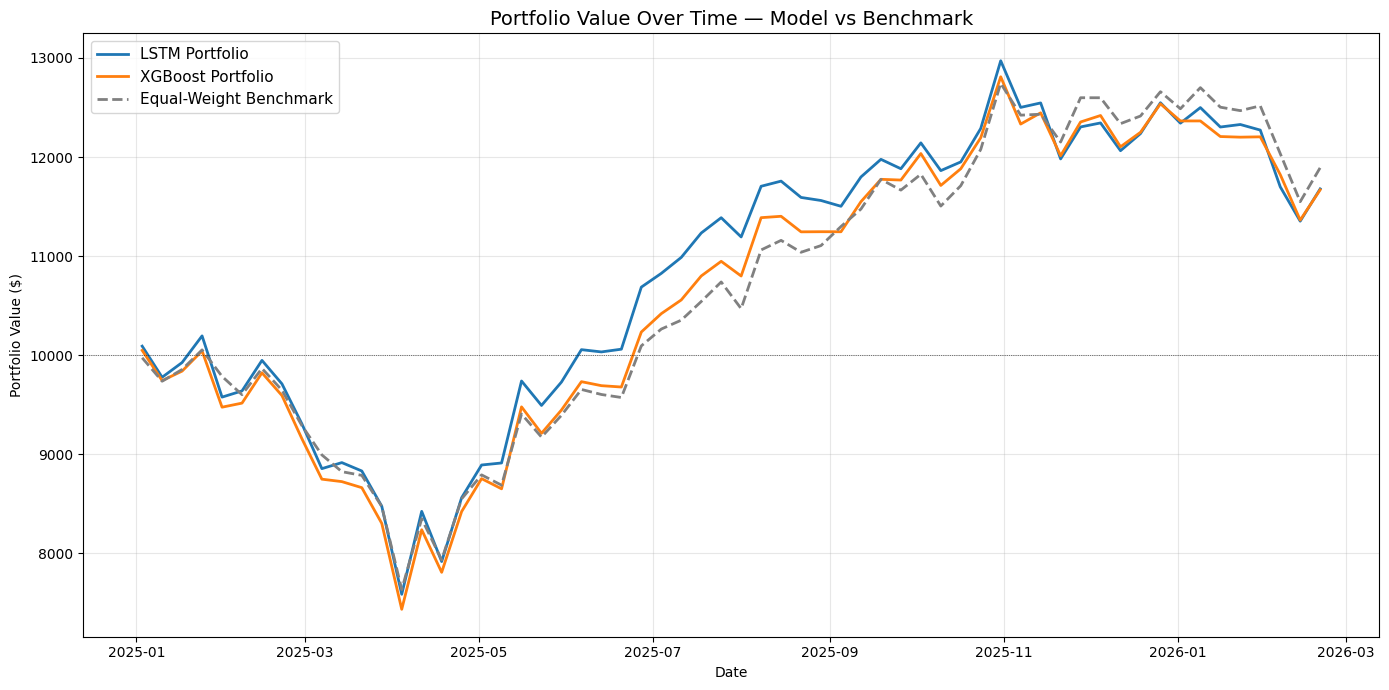

Saved: data/results/portfolio_comparison.png


In [15]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(lstm_val.index, lstm_val, label='LSTM Portfolio', linewidth=2, color='#1f77b4')
ax.plot(xgb_val.index, xgb_val, label='XGBoost Portfolio', linewidth=2, color='#ff7f0e')
ax.plot(equal_val.index, equal_val, label='Equal-Weight Benchmark', linewidth=2, color='gray', linestyle='--')
ax.axhline(y=10000, color='black', linewidth=0.5, linestyle=':')
ax.set_title('Portfolio Value Over Time — Model vs Benchmark', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/portfolio_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/portfolio_comparison.png')

## 12. Allocation Heatmap

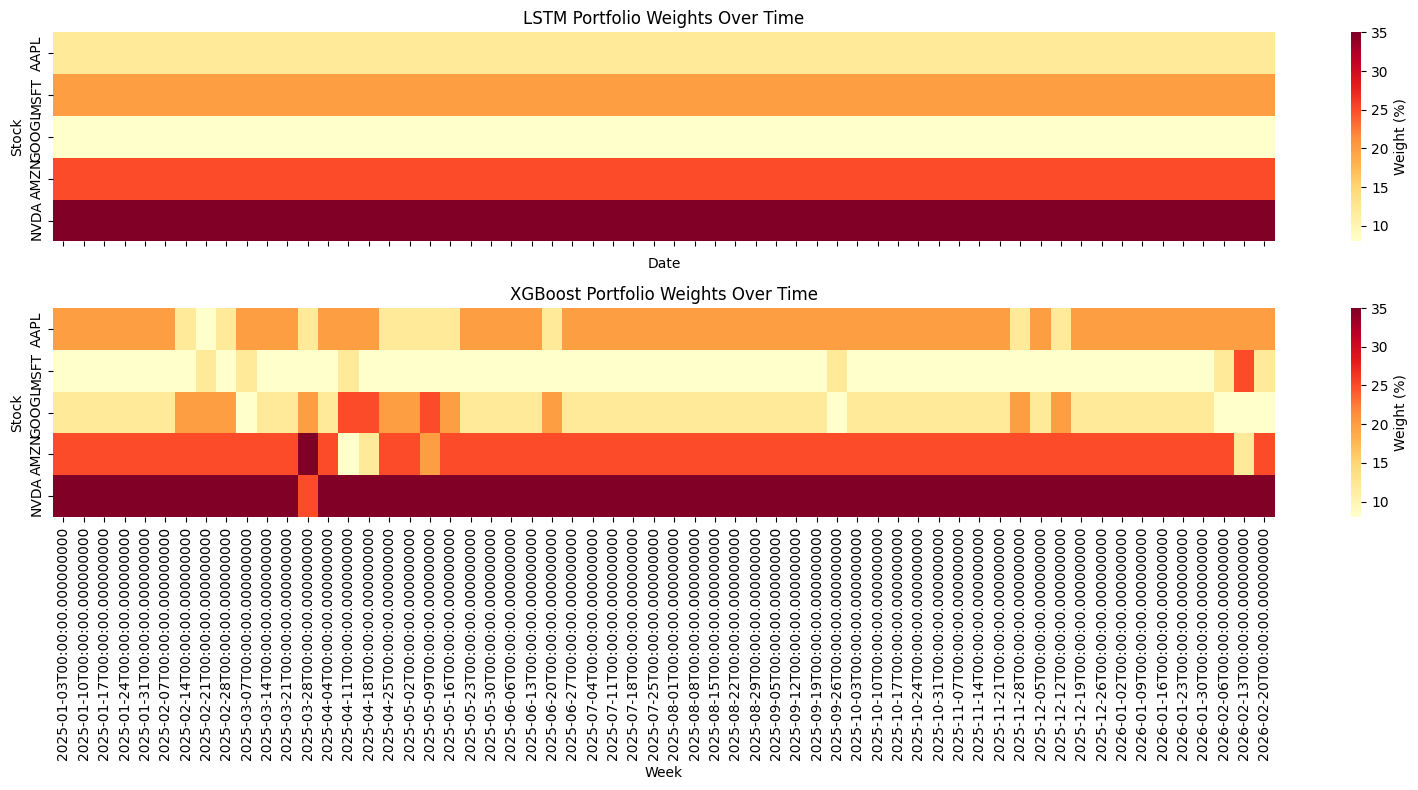

Saved: data/results/allocation_heatmap.png


In [16]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

sns.heatmap(lstm_weights.T * 100, cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'Weight (%)'}, linewidths=0, yticklabels=TICKERS)
axes[0].set_title('LSTM Portfolio Weights Over Time', fontsize=12)
axes[0].set_ylabel('Stock')
axes[0].set_xticklabels([])

sns.heatmap(xgb_weights.T * 100, cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Weight (%)'}, linewidths=0, yticklabels=TICKERS)
axes[1].set_title('XGBoost Portfolio Weights Over Time', fontsize=12)
axes[1].set_ylabel('Stock')
axes[1].set_xlabel('Week')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/allocation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/allocation_heatmap.png')

## 13. Drawdown Analysis

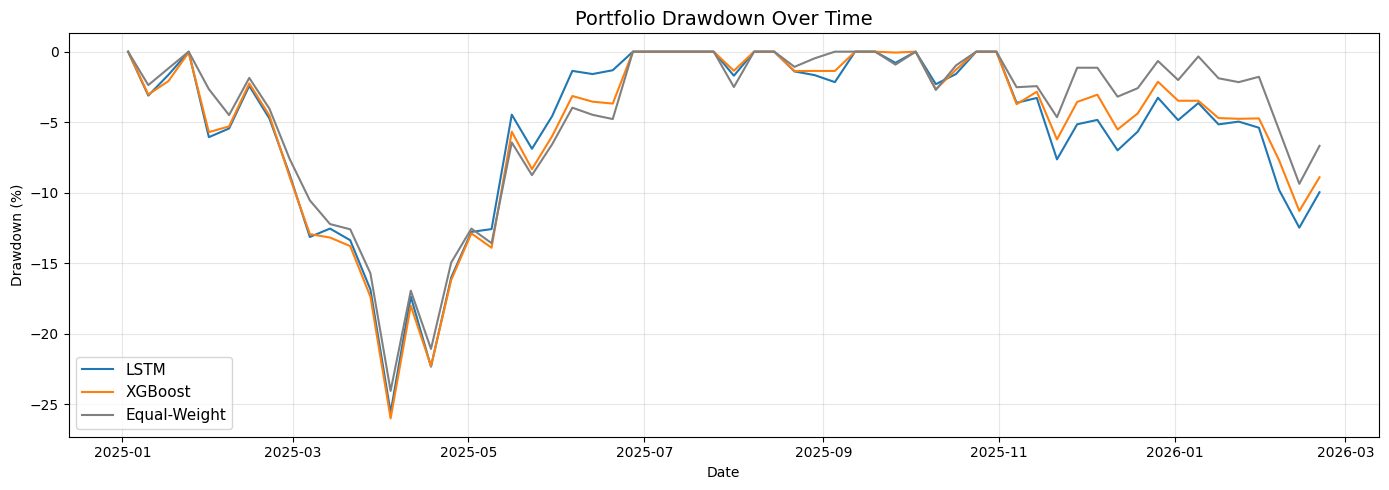

Saved: data/results/drawdown_analysis.png


In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

for returns, name, color in [
    (lstm_ret, 'LSTM', '#1f77b4'),
    (xgb_ret, 'XGBoost', '#ff7f0e'),
    (equal_ret, 'Equal-Weight', 'gray')
]:
    cumulative = (1 + returns).cumprod()
    drawdown = (cumulative - cumulative.cummax()) / cumulative.cummax() * 100
    ax.plot(drawdown.index, drawdown, label=name, linewidth=1.5, color=color)

ax.set_title('Portfolio Drawdown Over Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/drawdown_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/drawdown_analysis.png')

## 14. Save All Results

In [18]:
portfolio_df = pd.DataFrame({
    'Date': lstm_val.index, 'LSTM_Value': lstm_val.values,
    'XGBoost_Value': xgb_val.values, 'EqualWeight_Value': equal_val.values
})
portfolio_df.to_csv(f'{OUT_DIR}/portfolio_values.csv', index=False)

returns_out = pd.DataFrame({
    'Date': lstm_ret.index, 'LSTM_Return': lstm_ret.values,
    'XGBoost_Return': xgb_ret.values, 'EqualWeight_Return': equal_ret.values
})
returns_out.to_csv(f'{OUT_DIR}/portfolio_returns.csv', index=False)

metrics_table.to_csv(f'{OUT_DIR}/portfolio_metrics.csv')
lstm_ranks.to_csv(f'{OUT_DIR}/lstm_weekly_ranks.csv')
xgb_ranks.to_csv(f'{OUT_DIR}/xgboost_weekly_ranks.csv')
actual_ranks.to_csv(f'{OUT_DIR}/actual_weekly_ranks.csv')

print('All results saved to', OUT_DIR)

All results saved to data/results


## 15. Final Summary

In [19]:
print('=' * 60)
print('  FINAL PORTFOLIO SUMMARY')
print('=' * 60)
print(f'\nTest Period: {common_dates.min().date()} to {common_dates.max().date()}')
print(f'Total Weeks: {len(common_dates)}')
print(f'\nStarting Investment: $10,000')
print(f'\n{"Strategy":<20} {"Final Value":>15} {"Total Return":>15} {"Sharpe":>10}')
print('-' * 60)
for _, row in metrics_table.iterrows():
    name = row.name
    fv = {'LSTM': lstm_val, 'XGBoost': xgb_val, 'Equal-Weight': equal_val}[name].iloc[-1]
    print(f'{name:<20} ${fv:>13,.2f} {row["Total Return"]:>15} {row["Sharpe Ratio"]:>10}')

print('\n' + '=' * 60)
print('  RANKING ACCURACY SUMMARY')
print('=' * 60)
for name, preds, ranks in [('LSTM', lstm_aligned, lstm_ranks), ('XGBoost', xgb_aligned, xgb_ranks)]:
    ra = ranking_accuracy(ranks, actual_ranks)
    t1 = top1_accuracy(preds, actual_aligned)
    t2 = top2_accuracy(preds, actual_aligned)
    print(f'\n{name}:')
    print(f'  Ranking accuracy: {ra:.1%}  (random: 20%)')
    print(f'  Top-1 accuracy:   {t1:.1%}  (random: 20%)')
    print(f'  Top-2 accuracy:   {t2:.1%}  (random: 40%)')

print('\nBacktest complete!')
print('Next: Add ARIMA predictions and S&P 500 / Nasdaq benchmarks.')

  FINAL PORTFOLIO SUMMARY

Test Period: 2025-01-03 to 2026-02-20
Total Weeks: 60

Starting Investment: $10,000

Strategy                 Final Value    Total Return     Sharpe
------------------------------------------------------------
LSTM                 $    11,678.66           16.8%       0.48
XGBoost              $    11,669.21           16.7%       0.49
Equal-Weight         $    11,892.36           18.9%       0.57

  RANKING ACCURACY SUMMARY

LSTM:
  Ranking accuracy: 19.0%  (random: 20%)
  Top-1 accuracy:   28.3%  (random: 20%)
  Top-2 accuracy:   41.7%  (random: 40%)

XGBoost:
  Ranking accuracy: 20.0%  (random: 20%)
  Top-1 accuracy:   28.3%  (random: 20%)
  Top-2 accuracy:   40.0%  (random: 40%)

Backtest complete!
Next: Add ARIMA predictions and S&P 500 / Nasdaq benchmarks.
